In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import hvplot.xarray
from scipy.ndimage import gaussian_filter

# Read CMEMS and grid

In [2]:
cmems = xr.open_dataset(os.path.join("P1D-m_1745438014042.nc")).isel(depth=slice(0,21))

In [3]:
cmems

<xarray.Dataset> Size: 255MB
Dimensions:      (time: 366, depth: 21, latitude: 25, longitude: 81)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1992-01-01
  * depth        (depth) float32 84B -0.0 2.0 4.0 6.0 ... 175.0 200.0 250.0
  * latitude     (latitude) float32 100B 64.0 64.12 64.25 ... 66.75 66.88 67.0
  * longitude    (longitude) float32 324B -28.0 -27.88 -27.75 ... -18.12 -18.0
Data variables:
    so           (time, depth, latitude, longitude) float32 62MB ...
    thetao       (time, depth, latitude, longitude) float32 62MB ...
    vxo          (time, depth, latitude, longitude) float32 62MB ...
    model_depth  (latitude, longitude) float32 8kB ...
    vyo          (time, depth, latitude, longitude) float32 62MB ...
    zos          (time, latitude, longitude) float32 3MB ...
    sithick      (time, latitude, longitude) float32 3MB ...
Attributes:
    Conventions:       CF-1.11
    title:             Arctic Ocean Physics Reanalysis
    institution:       NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:            NERSC-HYCOM model fields
    history:           20220829:Created by program hyc2proj, version V0.3
    references:        http://topaz.nersc.no
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  ARCTIC_MULTIYEAR_PHY_002_003
    subset:datasetId:  cmems_mod_arc_phy_my_topaz4_P1D-m_202211
    subset:date:       2025-04-23T19:53:34.043Z

In [4]:
#45:end,1:640

In [5]:
topo = xr.open_dataset('Isafjardardjup_topo.nc').isel(x=slice(44,None,2), y=slice(0,640,2))

In [6]:
lon_grid = topo.lonv.values
lat_grid = topo.latv.values

# Subset CMEMS for nearest available longitude

In [7]:
lon_tgt = -25 # nearest available
lat_tgt = lat_grid

In [8]:
cmems_subset = cmems.sel(longitude = lon_tgt, latitude = lat_tgt, method='nearest')

In [9]:
cmems_subset.so.isel(time=0, depth=12).hvplot(cmap='coolwarm')

:Curve   [latitude]   (Salinity)

In [10]:
cmems.thetao.isel(time=0, depth=0).hvplot(cmap='coolwarm')

:Image   [longitude,latitude]   (Sea Temperature)

In [11]:
cmems.model_depth.hvplot(cmap='ocean')

:Image   [longitude,latitude]   (Sea floor depth below sea level)

# Interpolate on z-centers

In [12]:
z_faces = [
      -190.0,
    -170.0,
      -150.0,
    -140.0,
    -130.0,
    -120.0,
    -110.0,
      -100.0,
    -90.0,
    -80.0,
    -70.0,
      -60.0,
      -50.0,
    -40.0,
      -30.0,
    -25.0,
      -20.0,
    -18.0,
    -16.0,
    -14.0,
    -12.0,
      -10.0,
    -8.0,
    -6.0,
    -5.0,
    -4.0,
    -3.0,
       -2.0,
    -1.0,
        0.0
]

In [13]:
z_centers = [(z_faces[i] + z_faces[i+1]) / 2 for i in range(len(z_faces) - 1)]

In [94]:
z_centers

[-180.0,
 -160.0,
 -145.0,
 -135.0,
 -125.0,
 -115.0,
 -105.0,
 -95.0,
 -85.0,
 -75.0,
 -65.0,
 -55.0,
 -45.0,
 -35.0,
 -27.5,
 -22.5,
 -19.0,
 -17.0,
 -15.0,
 -13.0,
 -11.0,
 -9.0,
 -7.0,
 -5.5,
 -4.5,
 -3.5,
 -2.5,
 -1.5,
 -0.5]

In [14]:
cmems_subset["depth"] = -cmems_subset.depth

### NB! Question here: how the array should be oriented in vertical direction??

## from cmems_subset to ds

In [15]:
ds = cmems_subset.rename({"longitude": "Nx", "latitude": "Ny", "depth": "Nz", "thetao": "T", "so": "S", "vxo": "u", "vyo": "v"})

In [16]:
ds = ds.isel(time=slice(None,-1))

In [17]:
ds = ds.interp(Nz=z_centers, method="linear")

## Fill NaN from 70 to 200 m

In [18]:
ds = ds.bfill(dim='Nz')

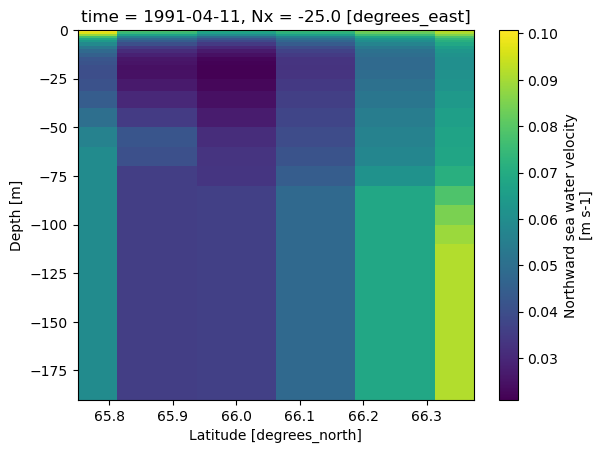

In [19]:
ds['v'].isel(time=100).plot()

In [20]:
ds

<xarray.Dataset> Size: 109MB
Dimensions:      (time: 365, Ny: 320, Nz: 29)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1991-12-31
  * Ny           (Ny) float32 1kB 65.75 65.75 65.75 65.75 ... 66.38 66.38 66.38
    Nx           float32 4B -25.0
  * Nz           (Nz) float64 232B -180.0 -160.0 -145.0 ... -2.5 -1.5 -0.5
Data variables:
    S            (time, Nz, Ny) float64 27MB 35.03 35.03 35.03 ... 34.96 34.96
    T            (time, Nz, Ny) float64 27MB 4.7 4.7 4.7 ... 4.599 4.599 4.599
    u            (time, Nz, Ny) float64 27MB 0.02076 0.02076 ... 0.05245 0.05245
    model_depth  (Ny) float32 1kB 78.02 78.02 78.02 78.02 ... 147.0 147.0 147.0
    v            (time, Nz, Ny) float64 27MB 0.03575 0.03575 ... -0.0003615
    zos          (time, Ny) float32 467kB -0.4435 -0.4435 ... -0.4738 -0.4738
    sithick      (time, Ny) float32 467kB 0.0 0.0 0.0 ... 1.328e-06 1.328e-06
Attributes:
    Conventions:       CF-1.11
    title:             Arctic Ocean Physics Reanalysis
    institution:       NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:            NERSC-HYCOM model fields
    history:           20220829:Created by program hyc2proj, version V0.3
    references:        http://topaz.nersc.no
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  ARCTIC_MULTIYEAR_PHY_002_003
    subset:datasetId:  cmems_mod_arc_phy_my_topaz4_P1D-m_202211
    subset:date:       2025-04-23T19:53:34.043Z

# Boundaries

## zeros containers

In [21]:
# grid params
nx = 299
ny = 320
nz = len(z_centers)

nt = 365 # 1 year

In [22]:
np_temp = np.zeros((nt, nz, ny, nx), dtype=np.float32)
np_salt = np.zeros((nt, nz, ny, nx), dtype=np.float32)
np_u = np.zeros((nt, nz, ny, nx+1), dtype=np.float32)
np_v = np.zeros((nt, nz, ny+1, nx), dtype=np.float32)

## get arrays from ds and smooth

In [23]:
tcmems = gaussian_filter(ds['T'].values, sigma=(0.2,0.1,15))
scmems = gaussian_filter(ds['S'].values, sigma=(0.2,0.1,15))
ucmems = gaussian_filter(ds['u'].values, sigma=(0.2,0.1,15))
vcmems = gaussian_filter(ds['v'].values, sigma=(0.2,0.1,15))

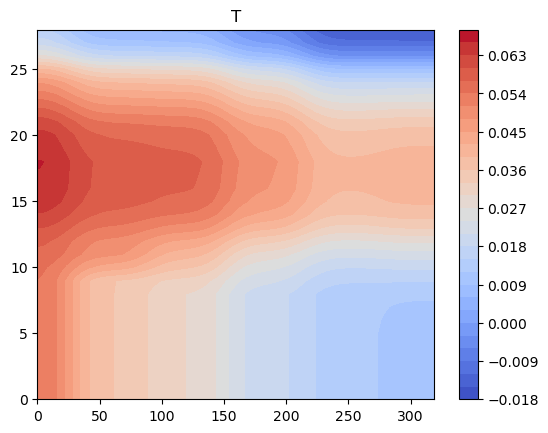

In [24]:
plt.contourf(vcmems[50,:,:], cmap='coolwarm', levels=30)
plt.title('T')
plt.colorbar()

In [25]:
vcmems.shape

(365, 29, 320)

In [26]:
vcmems2 = np.concat((vcmems, vcmems[:,:,-1, np.newaxis]), axis=2)

In [27]:
np_temp[:,:,:,0] = tcmems
np_temp[:,:,-1,:] = np.repeat(tcmems[:,:,-1, np.newaxis], nx, axis=2)

np_salt[:,:,:,0] = scmems
np_salt[:,:,-1,:] = np.repeat(scmems[:,:,-1, np.newaxis], nx, axis=2)

np_u[:,:,:,0] = ucmems
np_u[:,:,-1,:] = np.repeat(ucmems[:,:,-1, np.newaxis], nx+1, axis=2)

np_v[:,:,:,0] = vcmems2
np_v[:,:,-1,:] = np.repeat(vcmems2[:,:,-1, np.newaxis], nx, axis=2)

# Rivers

In [29]:
grid_depth = topo.depth.values

## figure out the position of the river
https://www.researchgate.net/figure/A-topographic-map-of-Iceland-with-the-main-river-systems-and-glaciated-areas_fig1_239789531

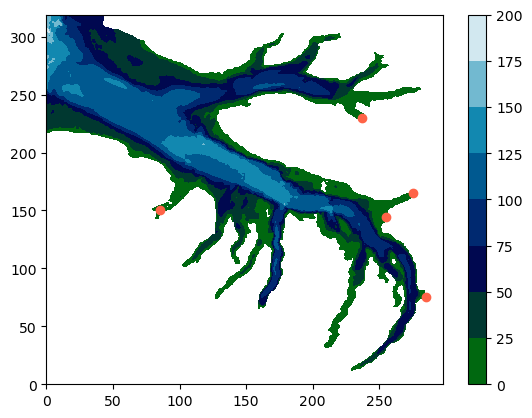

In [61]:
cf = plt.contourf(grid_depth, cmap='ocean')
plt.scatter(237, 230, c='tomato')  # Leyrueyrar
plt.scatter(275, 165, c='tomato')  # Kaldalon
plt.scatter(255, 144, c='tomato')  # Sela + Hraundalsa
plt.scatter(285, 75, c='tomato')   # Myrar
plt.scatter(85, 150, c='tomato')   # Langa

#plt.xlim(80,100)
#plt.ylim(140,170)
plt.colorbar(cf)

In [62]:
xrivers = [238, 276, 256, 286, 86]
yrivers = [231, 166, 145, 76, 151]

## add river to salinity

In [63]:
np_salt[:,:,yrivers,xrivers] = 0

# Lambda

In [64]:
Tout_lambda = np.empty(np_temp.shape, dtype=np.float32)
Sout_lambda = np.empty(np_temp.shape, dtype=np.float32)
Uout_lambda = np.empty((nt, nz, ny, nx + 1), dtype=np.float32)
Vout_lambda = np.empty((nt, nz, ny + 1, nx), dtype=np.float32)

In [65]:
# Left
Tout_lambda[:, :, :, 0] = 1 / 60 / 60 / 24 / 10
Sout_lambda[:, :, :, 0] = 1 / 60 / 60 / 24 / 10
Uout_lambda[:, :, :, 0] = 1 / 60 / 60 / 24 / 10
Vout_lambda[:, :, :, 0] = 1 / 60 / 60 / 24 / 10

# Upper
Tout_lambda[:, :, -1, :] = 1 / 60 / 60 / 24 / 10
Sout_lambda[:, :, -1, :] = 1 / 60 / 60 / 24 / 10
Uout_lambda[:, :, -1, :] = 1 / 60 / 60 / 24 / 10
Vout_lambda[:, :, -1, :] = 1 / 60 / 60 / 24 / 10

# Rivers
Sout_lambda[:, :, yrivers, xrivers] = 1 / 60 / 60 / 24

Text(0.5, 1.0, 'lambda')

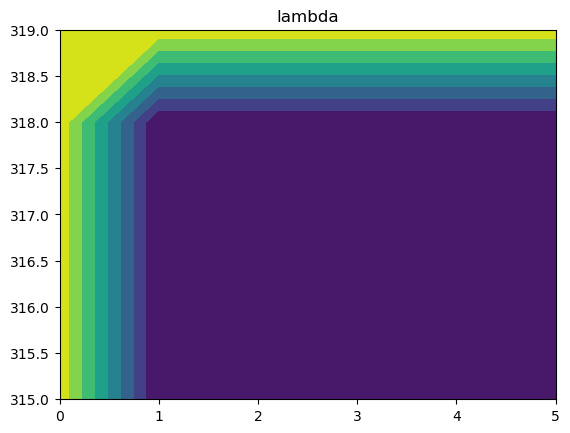

In [246]:
plt.contourf(Tout_lambda[0,0])
plt.xlim(0,5)
plt.ylim(315,319)
plt.title('lambda')

# Output file

In [66]:
lon_grid.min(), lon_grid.max()

(np.float64(-23.491999999999997), np.float64(-22.3))

In [67]:
lons = np.linspace(-23.492, -22.3, num=nx)
lons_faces = np.linspace(-23.492, -22.3, num=nx + 1)
lats = np.linspace(65.76, 66.399, num= ny)
lats_faces = np.linspace(65.76, 66.399, num=ny + 1)

In [68]:
np_time = ds.time.values

In [70]:
np_time

array(['1991-01-01T00:00:00.000000000', '1991-01-02T00:00:00.000000000',
       '1991-01-03T00:00:00.000000000', '1991-01-04T00:00:00.000000000',
       '1991-01-05T00:00:00.000000000', '1991-01-06T00:00:00.000000000',
       '1991-01-07T00:00:00.000000000', '1991-01-08T00:00:00.000000000',
       '1991-01-09T00:00:00.000000000', '1991-01-10T00:00:00.000000000',
       '1991-01-11T00:00:00.000000000', '1991-01-12T00:00:00.000000000',
       '1991-01-13T00:00:00.000000000', '1991-01-14T00:00:00.000000000',
       '1991-01-15T00:00:00.000000000', '1991-01-16T00:00:00.000000000',
       '1991-01-17T00:00:00.000000000', '1991-01-18T00:00:00.000000000',
       '1991-01-19T00:00:00.000000000', '1991-01-20T00:00:00.000000000',
       '1991-01-21T00:00:00.000000000', '1991-01-22T00:00:00.000000000',
       '1991-01-23T00:00:00.000000000', '1991-01-24T00:00:00.000000000',
       '1991-01-25T00:00:00.000000000', '1991-01-26T00:00:00.000000000',
       '1991-01-27T00:00:00.000000000', '1991-01-28

In [71]:
dsout = xr.Dataset(
    {
        "T": (["time", "Nz", "Ny", "Nx"], np_temp),
        "T_lambda": (["time", "Nz", "Ny", "Nx"], Tout_lambda),
        "S": (["time", "Nz", "Ny", "Nx"], np_salt),
        "S_lambda": (["time", "Nz", "Ny", "Nx"], Sout_lambda),
        "u": (["time", "Nz", "Ny", "Nx_faces"], np_u),
        "u_lambda": (["time", "Nz", "Ny", "Nx_faces"], Uout_lambda),
        "v": (["time", "Nz", "Ny_faces", "Nx"], np_v),
        "v_lambda": (["time", "Nz", "Ny_faces", "Nx"], Vout_lambda),
    },
    coords={
        "time": np_time,
        "Nz": z_centers,
        "Ny": lats,
        "Ny_faces": lats_faces,
        "Nx": lons,
        "Nx_faces": lons_faces,
    },
)

In [72]:
dsout = dsout.fillna(-999)

In [253]:
365*29*320*300

1016160000

In [73]:
dsout

<xarray.Dataset> Size: 32GB
Dimensions:   (time: 365, Nz: 29, Ny: 320, Nx: 299, Nx_faces: 300, Ny_faces: 321)
Coordinates:
  * time      (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1991-12-31
  * Nz        (Nz) float64 232B -180.0 -160.0 -145.0 -135.0 ... -2.5 -1.5 -0.5
  * Ny        (Ny) float64 3kB 65.76 65.76 65.76 65.77 ... 66.39 66.39 66.4 66.4
  * Ny_faces  (Ny_faces) float64 3kB 65.76 65.76 65.76 65.77 ... 66.4 66.4 66.4
  * Nx        (Nx) float64 2kB -23.49 -23.49 -23.48 ... -22.31 -22.3 -22.3
  * Nx_faces  (Nx_faces) float64 2kB -23.49 -23.49 -23.48 ... -22.31 -22.3 -22.3
Data variables:
    T         (time, Nz, Ny, Nx) float32 4GB 4.701 0.0 0.0 ... 4.601 4.601 4.601
    T_lambda  (time, Nz, Ny, Nx) float32 4GB 1.157e-06 0.0 ... 1.157e-06
    S         (time, Nz, Ny, Nx) float32 4GB 35.04 0.0 0.0 ... 34.96 34.96 34.96
    S_lambda  (time, Nz, Ny, Nx) float32 4GB 1.157e-06 0.0 ... 1.157e-06
    u         (time, Nz, Ny, Nx_faces) float32 4GB 0.02024 0.0 ... 0.05238
    u_lambda  (time, Nz, Ny, Nx_faces) float32 4GB 1.157e-06 0.0 ... 1.157e-06
    v         (time, Nz, Ny_faces, Nx) float32 4GB 0.03452 0.0 ... -0.0003998
    v_lambda  (time, Nz, Ny_faces, Nx) float32 4GB 1.157e-06 0.0 ... 1.157e-06

In [74]:
dsout.isel(time=np.arange(0,365,3)).to_netcdf('Isf_bry_299x320_3d.nc')

In [21]:
Nt, Nz, Ny, Nx = ds["T"].shape

In [22]:
Uout = np.full((Nt, Nz, Ny, Nx + 1), 0, dtype=np.float32)
Uout_lambda = np.full((Nt, Nz, Ny, Nx + 1), 1 / 60 / 60 / 24 / 20, dtype=np.float32)
Vout = np.full((Nt, Nz, Ny + 1, Nx), 0.05, dtype=np.float32)
Vout_lambda = np.full((Nt, Nz, Ny + 1, Nx), 1 / 60 / 60 / 24 / 20, dtype=np.float32)

Uout[:,:-6,:,:] = np.nan
Vout[:,:-6,:,:] = np.nan
Uout_lambda[:,:-6,:,:] = np.nan
Vout_lambda[:,:-6,:,:] = np.nan